In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [5]:
def zoom_image(img: np.ndarray, s: float, method: str = "nearest") -> np.ndarray:
    if not (0.0 < s <= 10.0):
        raise ValueError("s must be in (0, 10].")
    if method not in ("nearest", "bilinear"):
        raise ValueError("method must be 'nearest' or 'bilinear'.")
    if img.dtype != np.uint8:
        raise TypeError("Expected uint8 image.")

    if img.ndim == 2:
        h, w = img.shape
        single = True
        im = img[..., np.newaxis]
    else:
        h, w, c = img.shape
        single = False
        im = img

    oh = max(1, int(round(h * s)))
    ow = max(1, int(round(w * s)))

    xs = np.linspace(0, w - 1, ow, dtype=np.float64)
    ys = np.linspace(0, h - 1, oh, dtype=np.float64)
    xi, yi = np.meshgrid(xs, ys)

    if method == "nearest":
        xc = np.clip(np.round(xi), 0, w - 1).astype(np.intp)
        yc = np.clip(np.round(yi), 0, h - 1).astype(np.intp)
        out = im[yc, xc]
    else:
        x0 = np.floor(xi).astype(np.intp)
        y0 = np.floor(yi).astype(np.intp)
        x1 = np.minimum(x0 + 1, w - 1)
        y1 = np.minimum(y0 + 1, h - 1)
        wx = (xi - x0)[..., np.newaxis]
        wy = (yi - y0)[..., np.newaxis]
        Ia = im[y0, x0].astype(np.float64)
        Ib = im[y0, x1].astype(np.float64)
        Ic = im[y1, x0].astype(np.float64)
        Id = im[y1, x1].astype(np.float64)
        out = (1.0 - wx) * (1.0 - wy) * Ia + wx * (1.0 - wy) * Ib
        out += (1.0 - wx) * wy * Ic + wx * wy * Id
        out = np.clip(np.round(out), 0, 255).astype(np.uint8)

    if single:
        return out[..., 0]
    return out


def normalized_ssd(a: np.ndarray, b: np.ndarray) -> tuple[float, float]:
    """Return (mse, nmse) with NMSE = MSE / (var(b) + eps), b = reference."""
    a = a.astype(np.float64) / 255.0
    b = b.astype(np.float64) / 255.0
    mse = float(np.mean((a - b) ** 2))
    v = float(np.var(b))
    nmse = mse / (v + 1e-8)
    return mse, nmse

No separate large Taylor file found — using synthetic reference: LANCZOS4 upscale then AREA downscale; comparing zoom(small_ds) to large_ref.
Output size from zoom: 200 x 112 (scale S=4)
Nearest-neighbor  — MSE: 0.001345,  normalized SSD (MSE/var): 0.041266
Bilinear          — MSE: 0.000713,  normalized SSD (MSE/var): 0.021881


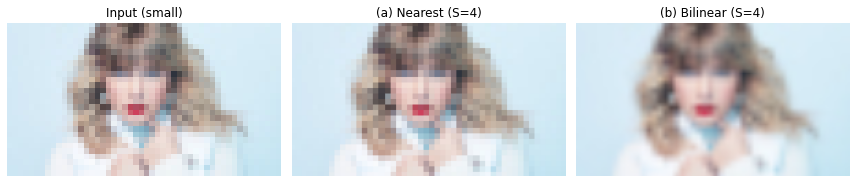

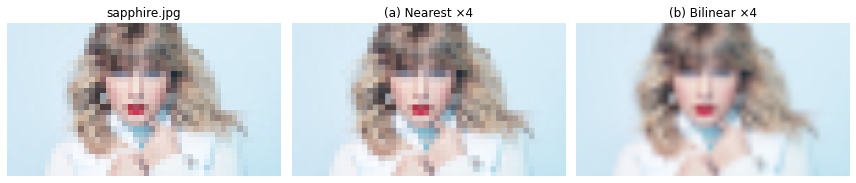

MSE(our bilinear, cv2.INTER_LINEAR): 0.00019220  (sanity check)


In [6]:
small_path = "images/taylor_very_small.jpg"
small = cv2.imread(small_path)
if small is None:
    raise FileNotFoundError(small_path)

h, w = small.shape[:2]
S = 4  # upscale factor to build reference and test

# Optional: true large original if you add it to images/
candidates = [
    "images/taylor.jpg",
    "images/taylor_large.jpg",
    "images/taylor_original.jpg",
]
large_ref = None
for p in candidates:
    if os.path.isfile(p):
        large_ref = cv2.imread(p)
        if large_ref is not None and large_ref.shape[0] >= h and large_ref.shape[1] >= w:
            print("Using ground-truth large image:", p)
            break
        large_ref = None

if large_ref is None:
    # Synthetic pair: high-res reference, area-downsampled small (same scene as taylor)
    oh, ow = int(round(h * S)), int(round(w * S))
    large_ref = cv2.resize(small, (ow, oh), interpolation=cv2.INTER_LANCZOS4)
    small_ds = cv2.resize(large_ref, (w, h), interpolation=cv2.INTER_AREA)
    print(
        "No separate large Taylor file found — using synthetic reference:",
        "LANCZOS4 upscale then AREA downscale; comparing zoom(small_ds) to large_ref.",
    )
    compare_small = small_ds
else:
    Lh, Lw = large_ref.shape[:2]
    S = float(min(Lw / w, Lh / h))
    tw, th = int(round(w * S)), int(round(h * S))
    large_ref = cv2.resize(large_ref, (tw, th), interpolation=cv2.INTER_AREA)
    compare_small = small
    print(f"Using file ground truth; effective scale S ≈ {S:.4f}")

up_nn = zoom_image(compare_small, S, method="nearest")
up_bl = zoom_image(compare_small, S, method="bilinear")

if up_nn.shape[:2] != large_ref.shape[:2]:
    large_ref = cv2.resize(large_ref, (up_bl.shape[1], up_bl.shape[0]), interpolation=cv2.INTER_LINEAR)

mse_nn, nmse_nn = normalized_ssd(up_nn, large_ref)
mse_bl, nmse_bl = normalized_ssd(up_bl, large_ref)

print(f"Output size from zoom: {up_bl.shape[1]} x {up_bl.shape[0]} (scale S={S})")
print(f"Nearest-neighbor  — MSE: {mse_nn:.6f},  normalized SSD (MSE/var): {nmse_nn:.6f}")
print(f"Bilinear          — MSE: {mse_bl:.6f},  normalized SSD (MSE/var): {nmse_bl:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(compare_small, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input (small)")
axes[1].imshow(cv2.cvtColor(up_nn, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"(a) Nearest (S={S})")
axes[2].imshow(cv2.cvtColor(up_bl, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"(b) Bilinear (S={S})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Extra: zoom the actual `sapphire.jpg` (SSD test above may use downscaled version)
S_viz = 4
viz_nn = zoom_image(small, S_viz, method="nearest")
viz_bl = zoom_image(small, S_viz, method="bilinear")
fig2, ax2 = plt.subplots(1, 3, figsize=(12, 4))
ax2[0].imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
ax2[0].set_title("sapphire.jpg")
ax2[1].imshow(cv2.cvtColor(viz_nn, cv2.COLOR_BGR2RGB))
ax2[1].set_title(f"(a) Nearest ×{S_viz}")
ax2[2].imshow(cv2.cvtColor(viz_bl, cv2.COLOR_BGR2RGB))
ax2[2].set_title(f"(b) Bilinear ×{S_viz}")
for ax in ax2:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Quick sanity: bilinear vs OpenCV linear resize (should be very close)
cv_lin = cv2.resize(compare_small, (up_bl.shape[1], up_bl.shape[0]), interpolation=cv2.INTER_LINEAR)
mse_cv, _ = normalized_ssd(up_bl, cv_lin)
print(f"MSE(our bilinear, cv2.INTER_LINEAR): {mse_cv:.8f}  (sanity check)")